# Inference Guide for the VAE

This notebook is an end-to-end walkthrough for running inference with the SVG VAE.

1. Load a pretrained checkpoint and model configuration.
2. Build one glyph samples from SVG files.
3. Reconstruct a given word.
4. Visualize interpolation between two fonts in latent space.
5. Apply self-refinement (alignment/continuity) and compare outputs.
6. Save generated glyphs back to SVG files for downstream inspection or export.

The notebook operates on real data from `demo_data/` and leverages the inference interface defined in [`designet/vae/tools.py`](designet/vae/tools.py), which provides all the required methods for running inference.

---
## Environment, Paths, and Expected Layout

Before running inference, verify the repository layout expected by this notebook:

```text
DesigNet/
  checkpoints/
    VAE.ckpt
  demo_data/
    SampleFont/
      *.svg
    SampleFontBold/
      *.svg
  demo_outputs/
    (created automatically)
```

Path conventions used below:

- `PROJECT_ROOT` is set to the `DesigNet/` folder.
- `checkpoint_path` points to `PROJECT_ROOT / "checkpoints" / "VAE.ckpt"`.
- `font_dir` points to one folder containing glyph SVGs for a single font.

Checkpoint availability note:

- `load_vae_model()` from [`designet/tools.py`](designet/tools.py) will automatically download a pretrained checkpoint from HuggingFace if no checkpoint is available. 

The import cell installs the package in editable mode so modules under `designet/` can be imported directly.

In [14]:
!pip install -e .

Obtaining file:///home/iago/workspace/DesigNet
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for designet (pyproject.toml) ... done
  Created wheel for designet: filename=designet-1.0-0.editable-py3-none-any.whl size=4146 sha256=39e94c51cca1079b9da92e88a4869a8e561b307279a69e416dea427083db4244
  Stored in directory: /tmp/pip-ephem-wheel-cache-kp7_kuqa/wheels/d1/15/68/a86d3298ad12b6a0529abfead1de815251230e72e2aa331a95
Successfully built designet
  Attempting uninstall: designet
    Found existing installation: designet 1.0
    Uninstalling designet-1.0:
      Successfully uninstalled designet-1.0

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [1]:
from pathlib import Path
import sys
import torch
from matplotlib import pyplot as plt
import string
import math

PROJECT_ROOT = Path(".").resolve()

from designet.vae.tools import (
    load_vae_model,
    reconstruct,
    plot_word_from_glyph_set,
    save_svg_from_cmd_args,
    svg_from_cmd_args,
    interpolate_two_glyphs_linear,
    refine_output_with_soft_refinement,
)

from designet.vae.glyph_loader import GlyphLoader, GlyphLoaderConfig

/home/tomas/anaconda3/envs/fontia/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"

font_dir = PROJECT_ROOT / "demo_data" / "SampleFont"

print("device:", device)
print("font_dir:", font_dir)

device: cpu
font_dir: /home/tomas/DesigNet/demo_data/SampleFont


/home/tomas/anaconda3/envs/fontia/lib/python3.10/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12070). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


---
## Load Pretrained Checkpoint

In [3]:
model, cfg, ckpt = load_vae_model(device=device, strict=False)

print("Loaded model.")

Download complete.
[load warning] Unexpected keys: ['loss_fn.cmd_args_mask']
Loaded model.


---
## Initialize Glyph Loader

The loader converts SVG glyph data into normalized command/argument tensors aligned with model expectations.

Configuration is driven directly from checkpoint metadata.

In [4]:
loader_cfg = GlyphLoaderConfig(
    max_num_groups=cfg["max_num_groups"],
    max_seq_len=cfg["max_seq_len"],
    normalize=True,
    center=True,
    compute_continuity=False,
    compute_line_alignment=False,
)

loader = GlyphLoader(font_dir, loader_cfg)

---
## Word Reconstruction

This section runs the VAE for self-reconstruction and plots results for comparison.

Word used: designet


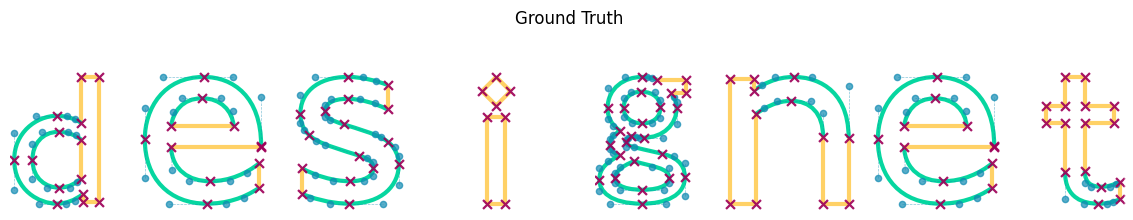

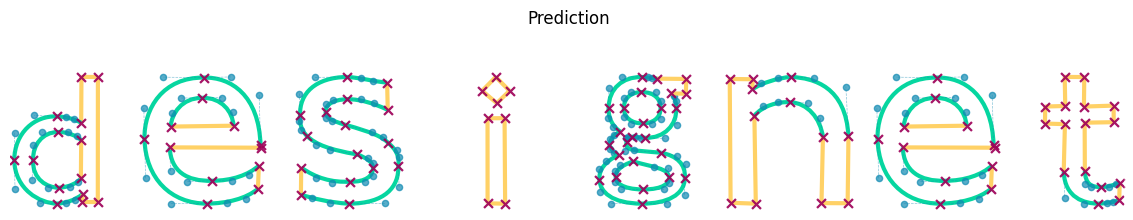

In [5]:
word = "designet"
glyph_names = list(dict.fromkeys(word))

samples = [loader.get(g) for g in glyph_names]
if not samples:
    raise ValueError("No valid glyph samples could be loaded")

sample_batch = GlyphLoader.collate_samples_batch(samples)
recon_batch = reconstruct(
    model=model,
    sample=sample_batch,
    device=device,
    close_paths=True,
)

gt_cmds = sample_batch["commands"]
gt_args = sample_batch["args"]
pr_cmds = recon_batch["commands"]
pr_args = recon_batch["args"]

_ = plot_word_from_glyph_set(
    glyph_commands=gt_cmds,
    glyph_args=gt_args,
    word=word,
    glyph_names=glyph_names,
    show_handles=True,
    panel_size=(1.5, 2.2),
    title="Ground Truth",
)

_ = plot_word_from_glyph_set(
    glyph_commands=pr_cmds,
    glyph_args=pr_args,
    word=word,
    glyph_names=glyph_names,
    show_handles=True,
    panel_size=(1.5, 2.2),
    title="Prediction",
)

print("Word used:", word)
plt.show()

---
## Exporting Reconstructed SVGs

The export utility writes generated glyphs as individual SVG files for external inspection.

In [6]:
# Save all predicted reconstructions from the word-level batch
out_dir = PROJECT_ROOT / "demo_outputs" / "vae_word_reconstructions"
out_dir.mkdir(parents=True, exist_ok=True)

saved_paths = []
for i, glyph_name in enumerate(glyph_names):
    saved = save_svg_from_cmd_args(
        commands=recon_batch["commands"][i],
        args=recon_batch["args"][i],
        output_path=out_dir / f"{glyph_name}_pred.svg",
    )
    saved_paths.append(saved["path"])

print(f"Saved {len(saved_paths)} reconstructed glyphs to: {out_dir}")

Saved 7 reconstructed glyphs to: /home/tomas/DesigNet/demo_outputs/vae_word_reconstructions


---
## Font Interpolation

This section interpolates between two font styles for the same glyph.

Interpolation follows linear blending in latent space:

$$
z_{\alpha} = (1-\alpha)z_A + \alpha z_B
$$

Latent codes are then passed through the model Decoder to obtain intermediate reconstructions.

In [7]:
font_dir_b = PROJECT_ROOT / "demo_data" / "SampleFontBold"
loader_b = GlyphLoader(font_dir_b, loader_cfg)

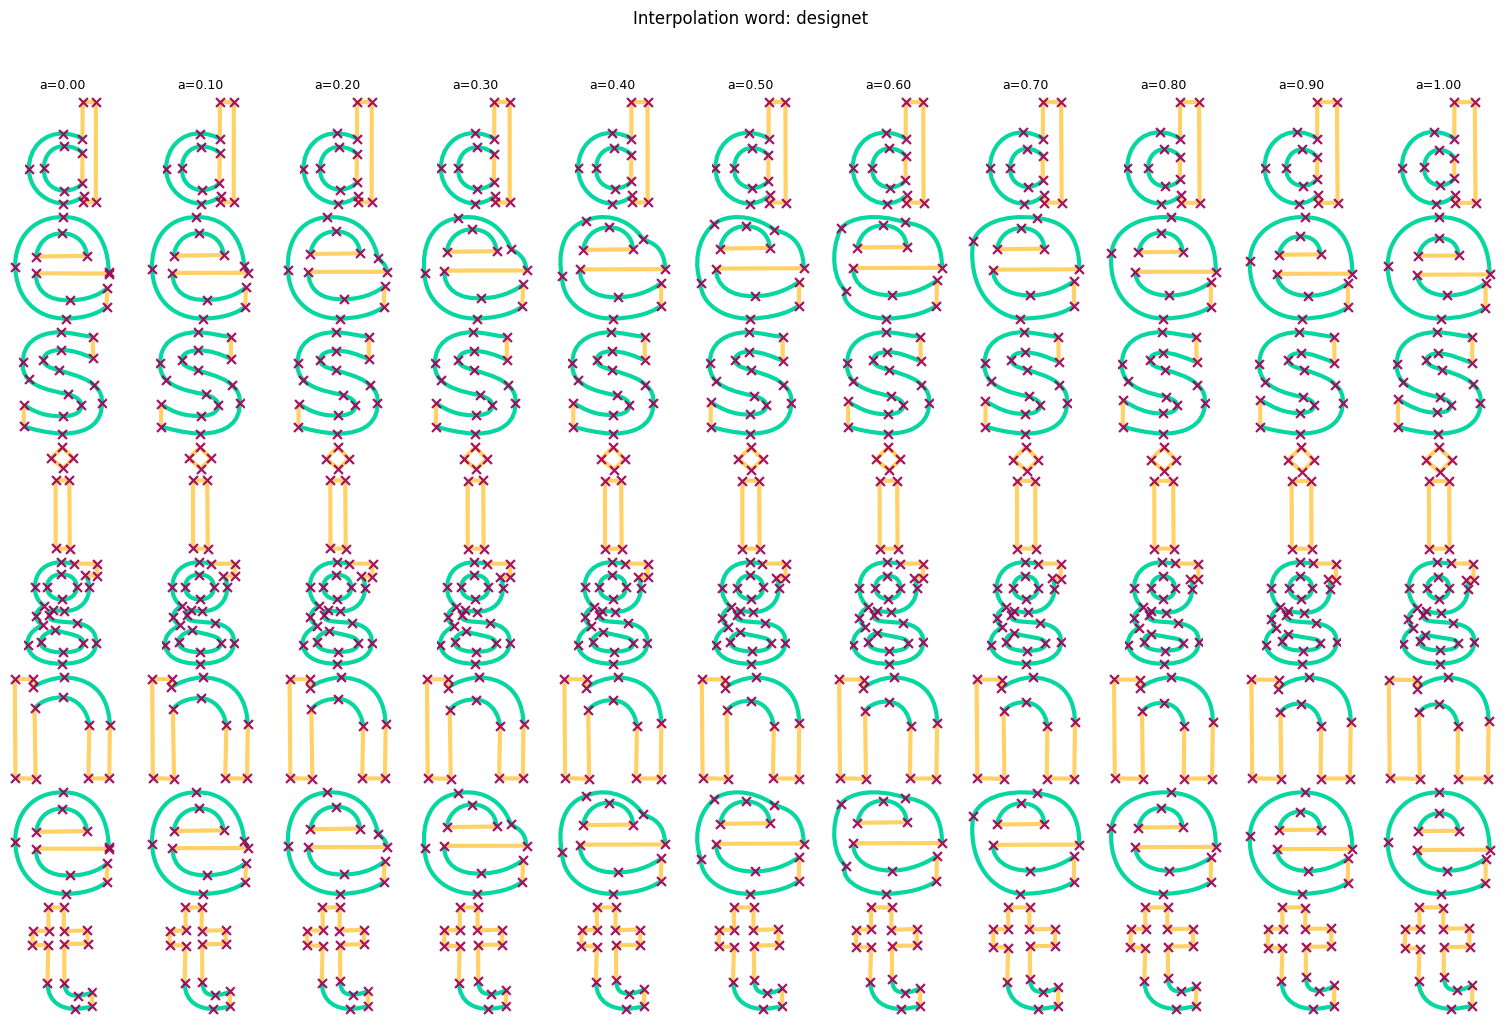

In [8]:
# Word-level interpolation: rows are glyphs, columns are interpolation steps
word = "designet"
alphas = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

# Keep unique order for loading, then index back by character
glyph_names = list(dict.fromkeys(word))
samples_a = {g: loader.get(g) for g in glyph_names}
samples_b = {g: loader_b.get(g) for g in glyph_names}

n_rows = len(word)
n_cols = len(alphas)
fig, axs = plt.subplots(
    n_rows,
    n_cols,
    figsize=(1.4 * n_cols, 1.3 * n_rows),
    squeeze=False,
)

for r, ch in enumerate(word):
    inter = interpolate_two_glyphs_linear(
        model=model,
        sample_a=samples_a[ch],
        sample_b=samples_b[ch],
        alphas=alphas,
        device=device,
        close_paths=True,
    )

    for c, (alpha, svg) in enumerate(zip(inter["alphas"], inter["svgs"])):
        ax = axs[r][c]
        svg.draw_matplotlib(ax, show_handles=False)
        ax.axis("off")
        if r == 0:
            ax.set_title(f"a={alpha:.2f}", fontsize=9)

    axs[r][0].set_ylabel(ch, rotation=0, labelpad=10, va="center", fontsize=9)

fig.suptitle(f"Interpolation word: {word}")
fig.tight_layout(rect=[0.0, 0.0, 1.0, 0.96])
fig.subplots_adjust(wspace=0.03, hspace=0.03)
plt.show()

---
## Self-Refinement (Alignment and Continuity)

After reconstruction, self-refinement can improve geometric consistency of path arguments.

The refinement pass uses predicted auxiliary logits:

- alignment logits: improve local geometric alignment
- continuity logits: improve path continuity transitions

Word used: selfrefinement


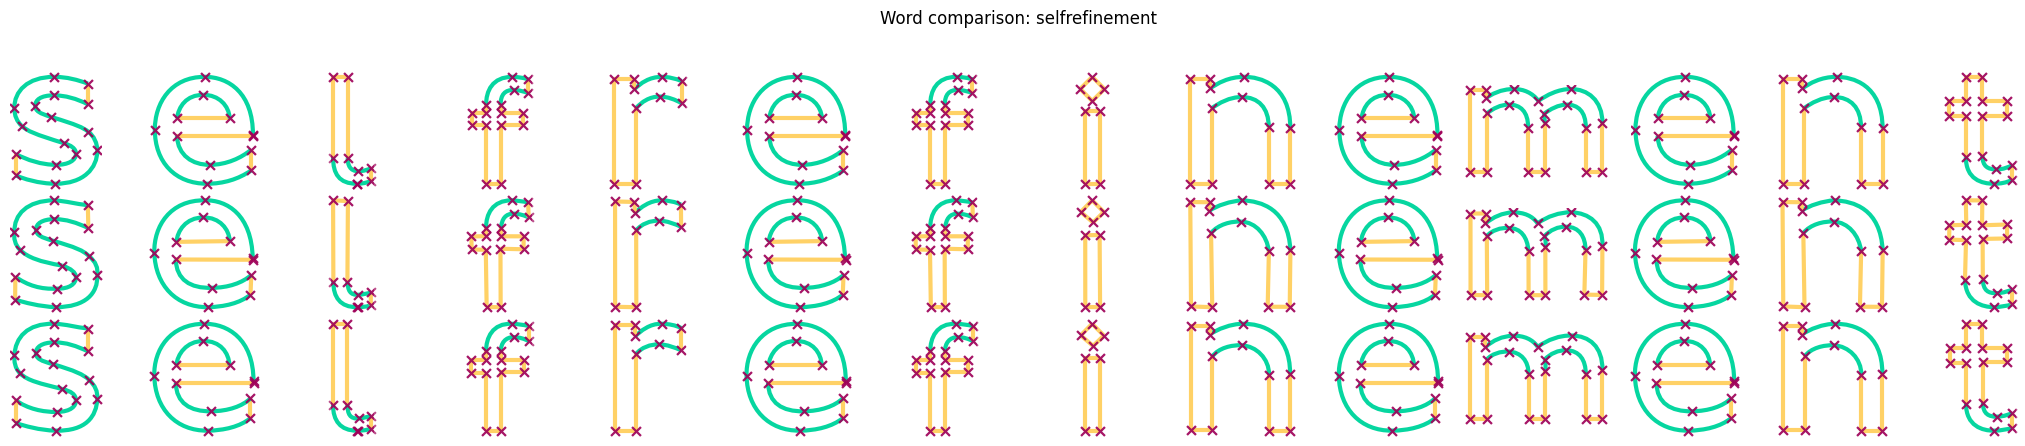

In [9]:
# Word-level 3-row comparison: GT, Pre-refinement, Post-refinement
word = "selfrefinement"
glyph_names = list(dict.fromkeys(word))

samples = [loader.get(g) for g in glyph_names]

sample_batch = GlyphLoader.collate_samples_batch(samples)
sample_dev = {k: (v.to(device) if torch.is_tensor(v) else v) for k, v in sample_batch.items()}

with torch.no_grad():
    out_pre = model(
        commands=sample_dev["commands"],
        args=sample_dev["args"],
        return_tgt=False,
    )

    out_post = refine_output_with_soft_refinement(out_pre)

    cmd_pre, arg_pre = model.greedy_sample(
        pred=out_pre,
        close_paths=True,
    )

    cmd_post, arg_post = model.greedy_sample(
        pred=out_post,
        close_paths=True,
    )

gt_cmds = sample_batch["commands"]
gt_args = sample_batch["args"]
pre_cmds = cmd_pre.detach().clone()
pre_args = arg_pre.detach().clone()
post_cmds = cmd_post.detach().clone()
post_args = arg_post.detach().clone()

name_to_idx = {g: i for i, g in enumerate(glyph_names)}
indices = [name_to_idx[ch] for ch in word]

n_rows, n_cols = 3, len(indices)
fig, axs = plt.subplots(
    n_rows,
    n_cols,
    figsize=(1.5 * n_cols, 1.5 * n_rows),
    squeeze=False,
)

row_specs = [
    ("GT", gt_cmds, gt_args),
    ("Pre-refinement", pre_cmds, pre_args),
    ("Post-refinement", post_cmds, post_args),
]

for r, (row_name, row_cmds, row_args) in enumerate(row_specs):
    for c, idx in enumerate(indices):
        svg = svg_from_cmd_args(
            row_cmds[idx],
            row_args[idx],
        )
        ax = axs[r][c]
        svg.draw_matplotlib(ax, show_handles=False)
        ax.axis("off")
    axs[r][0].set_ylabel(row_name, rotation=0, labelpad=18, va="center")

fig.suptitle(f"Word comparison: {word}")
fig.tight_layout(rect=[0.0, 0.0, 1.0, 0.95])
fig.subplots_adjust(wspace=0.02, hspace=0.05)
print("Word used:", word)
plt.show()

In [10]:
# Save post-refinement outputs (one SVG per glyph in the word set)
refined_out_dir = PROJECT_ROOT / "demo_outputs" / "vae_word_refined"
refined_out_dir.mkdir(parents=True, exist_ok=True)

refined_saved_paths = []
for i, glyph_name in enumerate(glyph_names):
    saved = save_svg_from_cmd_args(
        commands=post_cmds[i],
        args=post_args[i],
        output_path=refined_out_dir / f"{glyph_name}_refined.svg",
    )
    refined_saved_paths.append(saved["path"])

print(f"Saved {len(refined_saved_paths)} refined glyphs to: {refined_out_dir}")

Saved 9 refined glyphs to: /home/tomas/DesigNet/demo_outputs/vae_word_refined
